# GNN for Graph Level Predictions about Knots (Volume)

Juan José H. Beltrán

In [2]:
# Requirements:
# pip install numpy pandas scikit-learn torch torch_geometric matplotlib

In [3]:
import dataset
from torch_geometric.loader import DataLoader
from settings import *

## Create Dataset and Dataloader

In [4]:
train_loader, val_loader, deg, knot_dataset = dataset.load()

# Esto debería pasarse a dataset.py
testGeneralisazion = DataLoader(dataset.fetchDataset("datasets/meanAbove71WithGraph.csv")["dataPoint"], batch_size = BATCH_SIZE)

Dataset consists of  2381 train samples and  596 test samples
max_degree: 11


### Explore Dataset

Cada dataset contiene una fila por cada grafo. Cada grafo tiene a su vez:
- `x`: Tensor con las features de los nodos. En este caso contiene el grado del nodo (input features: 1).
- `edge_index`: Tensor con la descripción de las aristas del grafo, especificando su origen y destino.
- `edge_atrr`: Tensor con los atributos de cada arista del grafo. En este caso son la "distancia" y si está o no "alternando".
- `y`: Tensor con los labels. En este caso, es un único label para todo el grafo: el invariante a predecir.

In [5]:
knot_dataset = knot_dataset.dataPoint

In [6]:
knot_dataset[0].edge_index

tensor([[0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5],
        [3, 2, 4, 4, 2, 3, 0, 1, 5, 0, 1, 5, 0, 1, 2, 3]])

## Functions and Classes for GNN

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from settings import *

In [8]:
# Import custom GNN models from models.py
from models import PNAKnotNet
from models import GATKnotNet
from models import TransKnotNet

In [9]:
torch.manual_seed(31)
model = PNAKnotNet(deg)

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 20, min_lr = 0.00001)

In [10]:
def train(epoch):
    model.train()

    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)

        if LOSS == "abs":
            loss = (out.squeeze() - data.y).abs().mean() # Mean Absolute Error
        elif LOSS == "squared":
            loss = (out.squeeze() - data.y).square().mean() # Mean Squared Error

        loss.backward()
        total_loss += loss.item() * data.num_graphs
        optimizer.step()

    return total_loss / len(train_loader.dataset)

In [11]:
@torch.no_grad()
def test(loader):
    model.eval()

    total_error = 0
    for data in loader:
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        if LOSS=="abs":
            total_error += (out.squeeze() - data.y).abs().sum().item()
        elif LOSS=="squared":
            total_error += (out.squeeze() - data.y).square().sum().item()
    
    return total_error / len(loader.dataset)

## Train Model

In [12]:
history_train_loss = []
history_val_loss = []
history_gen_loss = []
history_gen_acc = []

for epoch in range(1, 200):
    val_loss = test(val_loader)
    # gen_loss, gen_acc = test(testGeneralisazion)
    loss = train(epoch)

    # Append history for plotting later
    history_train_loss.append(loss)
    history_val_loss.append(val_loss)
    # history_gen_loss.append(gen_loss)
    # history_gen_acc.append(gen_acc)

    scheduler.step(loss)
    print(f'Epoch: {epoch:02d}, Train loss: {loss:.4f}, Val loss: {val_loss:.4f}')
    # print(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, Val: {val_loss:.4f}, Acc: {val_acc:.4f}, Val on big: {gen_loss:.4f}, Acc on big: {gen_acc:.4f}')

Epoch: 01, Train loss: 233.3000, Val loss: 228.9913
Epoch: 02, Train loss: 216.8391, Val loss: 217.0835
Epoch: 03, Train loss: 187.6377, Val loss: 193.0563
Epoch: 04, Train loss: 148.4317, Val loss: 158.9770
Epoch: 05, Train loss: 108.5588, Val loss: 120.4396
Epoch: 06, Train loss: 75.5891, Val loss: 85.3125
Epoch: 07, Train loss: 51.7735, Val loss: 60.3122
Epoch: 08, Train loss: 37.3909, Val loss: 42.0254
Epoch: 09, Train loss: 28.0504, Val loss: 32.3637
Epoch: 10, Train loss: 21.5216, Val loss: 25.8708
Epoch: 11, Train loss: 17.7028, Val loss: 74.6123
Epoch: 12, Train loss: 14.0448, Val loss: 16.8218
Epoch: 13, Train loss: 11.9599, Val loss: 12.2293
Epoch: 14, Train loss: 10.3633, Val loss: 30.0788
Epoch: 15, Train loss: 10.5833, Val loss: 10.1635
Epoch: 16, Train loss: 10.0128, Val loss: 15.3151
Epoch: 17, Train loss: 10.0706, Val loss: 9.1364
Epoch: 18, Train loss: 10.0417, Val loss: 11.7464
Epoch: 19, Train loss: 9.7885, Val loss: 10.2859
Epoch: 20, Train loss: 9.8575, Val loss: 1

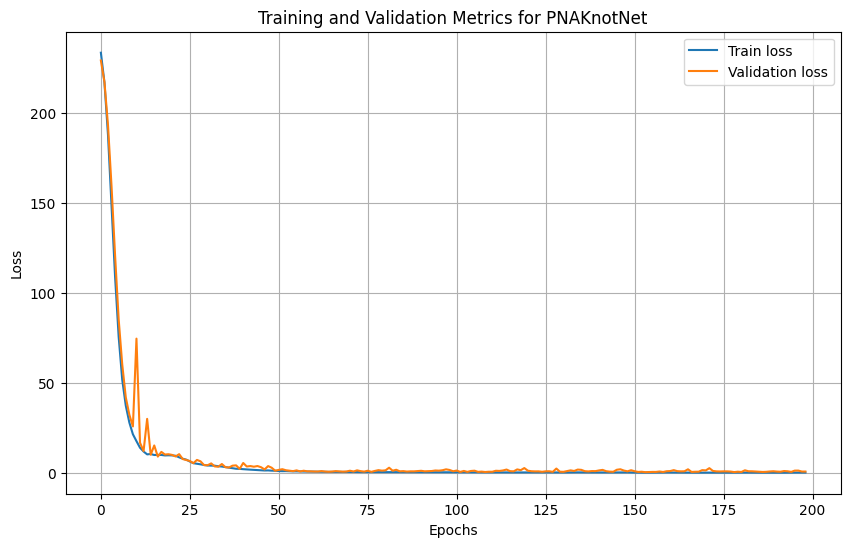

In [13]:
# Show graphs of loss and accuracy
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(history_train_loss, label = "Train loss")
plt.plot(history_val_loss, label = "Validation loss")
# plt.plot(history_gen_acc, label = "Generalization accuracy")
# plt.plot(history_gen_loss, label = "Generalization loss")

plt.title(f"Training and Validation Metrics for {model._get_name()}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Save the trained model
torch.save(model.state_dict(), f"models/{model._get_name()}_{FEATURE}_{LOSS}_bs{BATCH_SIZE}_add{ADDITIONAL}.pt")